In [3]:
import torch
import json
from pathlib import Path

import util.misc as utils
from torch.utils.data import DataLoader

from datasets import build_dataset, get_coco_api_from_dataset
from models import build_model
from engine import evaluate 


from evaluation.args import HeadArgs

def make_serializable(obj):
    import numpy as np
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    return obj


import logging
logging.basicConfig(level=logging.INFO)

if __name__ == '__main__':
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("GPU count:", torch.cuda.device_count())

    models_to_eval = [
        (1, r"C:\workspace\ml\workspace\master\original\results\baseline\1head\checkpoint.pth"),
        (2, r"C:\workspace\ml\workspace\master\original\results\baseline\2head\checkpoint.pth"),
        (3, r"C:\workspace\ml\workspace\master\original\results\baseline\3head\checkpoint.pth"),
        (4, r"C:\workspace\ml\workspace\master\original\results\baseline\4head\checkpoint.pth")
    ]

    for n_heads, model_path_str in models_to_eval:
        print(f"\n============================\nEvaluating {n_heads} heads model\n============================")
        args = HeadArgs(number_of_heads=n_heads)

        dataset_val = build_dataset(image_set='val', args=args)
        sampler_val = torch.utils.data.SequentialSampler(dataset_val)
        data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                        drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)
        base_ds = get_coco_api_from_dataset(dataset_val)

        model_path = Path(model_path_str)
        device = torch.device(args.device)
        model, criterion, postprocessors = build_model(args)
        model.to(device)
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        model.load_state_dict(checkpoint['model'])

        test_stats, coco_evaluator = evaluate(model, criterion, postprocessors,
                                                data_loader_val, base_ds, device, args.output_dir)

        output_path = Path(str("baseline_test_stats_heads{}.json").format(args.nheads))
        with open(output_path, "w") as f:
            json.dump(make_serializable(test_stats), f, indent=2)

        print(f"Saved to {output_path.resolve()}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU count: 1

Evaluating 1 heads model
loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
Test:  [   0/2500]  eta: 3:16:53  class_error: 38.10  loss: 12.9186 (12.9186)  loss_ce: 0.7868 (0.7868)  loss_bbox: 0.2916 (0.2916)  loss_giou: 1.0469 (1.0469)  loss_ce_0: 0.8499 (0.8499)  loss_bbox_0: 0.2712 (0.2712)  loss_giou_0: 0.9733 (0.9733)  loss_ce_1: 0.8491 (0.8491)  loss_bbox_1: 0.2939 (0.2939)  loss_giou_1: 1.0395 (1.0395)  loss_ce_2: 0.8304 (0.8304)  loss_bbox_2: 0.3197 (0.3197)  loss_giou_2: 1.0734 (1.0734)  loss_ce_3: 0.7819 (0.7819)  loss_bbox_3: 0.3133 (0.3133)  loss_giou_3: 1.0594 (1.0594)  loss_ce_4: 0.7785 (0.7785)  loss_bbox_4: 0.3065 (0.3065)  loss_giou_4: 1.0533 (1.0533)  loss_ce_unscaled: 0.7868 (0.7868)  class_error_unscaled: 38.0952 (38.0952)  loss_bbox_unscaled: 0.0583 (0.0583)  loss_giou_unscaled: 0.5234 (0.5234)  cardinality_error_unscaled: 12.0000 (12.0000)  loss_ce_0_unscaled: 0.8499 (0.

KeyboardInterrupt: 

In [ ]:

import torch
import json
from pathlib import Path

import util.misc as utils
from torch.utils.data import DataLoader

from datasets import build_dataset, get_coco_api_from_dataset
from sliced_models import build_model
from sliced_models.training.engine import evaluate as evaluate_sliced

model_name = "4heads_sliced_600epoch"

def make_serializable(obj):
    import numpy as np
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    return obj

from evaluation.args import HeadArgs

import logging
logging.basicConfig(level=logging.INFO)
args = HeadArgs(number_of_heads=4)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

dataset_val = build_dataset(image_set='val', args=args)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)
base_ds = get_coco_api_from_dataset(dataset_val)


model_path= r"C:\workspace\ml\workspace\master\original\results\sliced\600epoch\checkpoint.pth"
device = torch.device(args.device)
model, criterion, postprocessors = build_model(args)
model.to(device)
checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'])

heads = [1, 2, 3, 4]

sliced_test_stats, sliced_coco_evaluator = evaluate_sliced(model, criterion, postprocessors,
                                        data_loader_val, base_ds, device, args.output_dir, heads=heads)


output_path = Path("sliced_test_stats_heads{}.json".format(model_name))
with open(output_path, "w") as f:
    json.dump(make_serializable(sliced_test_stats), f, indent=2)

print(f"Saved to {output_path.resolve()}")

In [ ]:

import torch
import json
from pathlib import Path

import util.misc as utils
from torch.utils.data import DataLoader

from datasets import build_dataset, get_coco_api_from_dataset
from layer_scaling import build_model
from layer_scaling.training.engine import evaluate

model_name = "4heads_layer_scaling_600epoch"

def make_serializable(obj):
    import numpy as np
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    return obj

from evaluation.args import HeadArgs

import logging
logging.basicConfig(level=logging.INFO)
args = HeadArgs(number_of_heads=4)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

dataset_val = build_dataset(image_set='val', args=args)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)
base_ds = get_coco_api_from_dataset(dataset_val)


model_path= r"C:\workspace\ml\workspace\master\original\results\layer_scaling\600epoch\checkpoint.pth"
device = torch.device(args.device)
model, criterion, postprocessors = build_model(args)
model.to(device)
checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'])

layers = [1, 2, 3, 4, 5, 6]

sliced_test_stats, sliced_coco_evaluator = evaluate(model, criterion, postprocessors,
                                        data_loader_val, base_ds, device, args.output_dir, layers=layers )


output_path = Path("test_stats_layers{}.json".format(model_name))
with open(output_path, "w") as f:
    json.dump(make_serializable(sliced_test_stats), f, indent=2)

print(f"Saved to {output_path.resolve()}")


PyTorch version: 2.8.0+cu128
CUDA available: True
GPU count: 1
loading annotations into memory...


INFO:layer_scaling:Building Sliced DETR model...


Done (t=0.29s)
creating index...
index created!


c:\workspace\ml\envs\detrenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\workspace\ml\envs\detrenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Evaluating [layers_1] ---
Test [layers_1]:  [   0/2500]  eta: 3:00:36  class_error: 28.57  loss: 2.1004 (2.1004)  loss_ce: 0.8489 (0.8489)  loss_bbox: 0.3036 (0.3036)  loss_giou: 0.9479 (0.9479)  loss_ce_unscaled: 0.8489 (0.8489)  class_error_unscaled: 28.5714 (28.5714)  loss_bbox_unscaled: 0.0607 (0.0607)  loss_giou_unscaled: 0.4739 (0.4739)  cardinality_error_unscaled: 11.5000 (11.5000)  time: 4.3344  data: 3.7640  max mem: 681
Test [layers_1]:  [  10/2500]  eta: 0:19:43  class_error: 0.00  loss: 1.3025 (1.4274)  loss_ce: 0.4285 (0.5033)  loss_bbox: 0.2288 (0.2611)  loss_giou: 0.5883 (0.6630)  loss_ce_unscaled: 0.4285 (0.5033)  class_error_unscaled: 22.7273 (25.9289)  loss_bbox_unscaled: 0.0458 (0.0522)  loss_giou_unscaled: 0.2941 (0.3315)  cardinality_error_unscaled: 8.0000 (11.5000)  time: 0.4754  data: 0.3453  max mem: 900
Test [layers_1]:  [  20/2500]  eta: 0:11:58  class_error: 30.77  loss: 1.4222 (1.4945)  loss_ce: 0.5074 (0.5607)  loss_bbox: 0.2311 (0.2744)  loss_giou: 0.

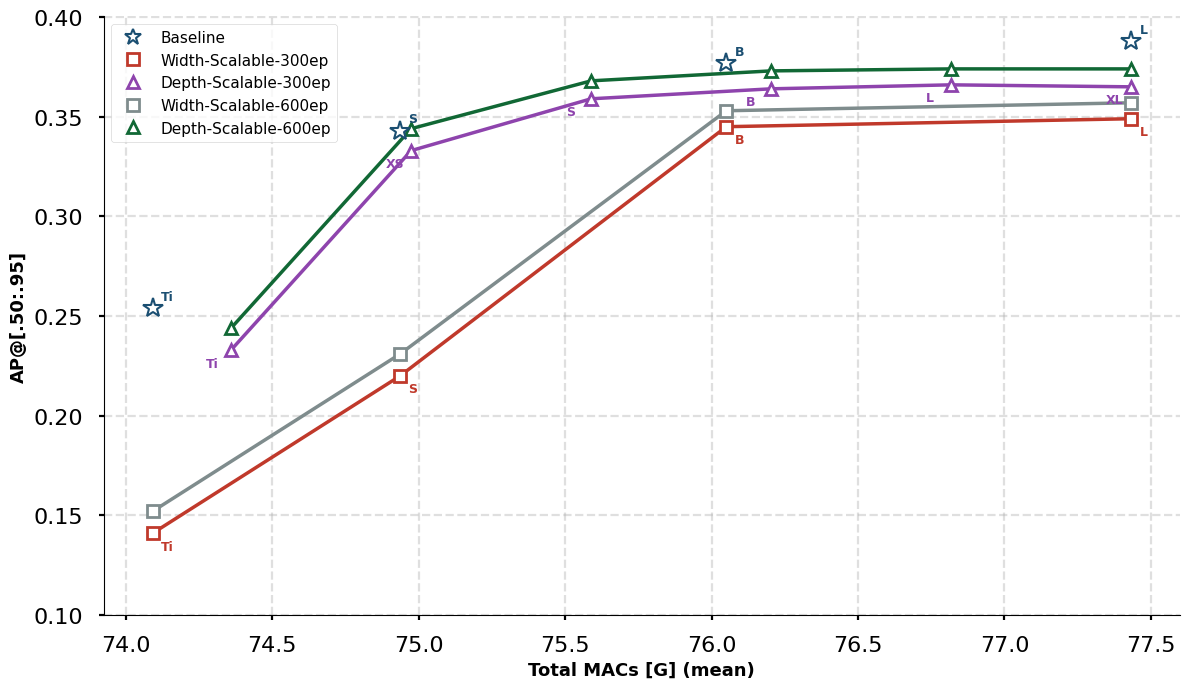

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from pathlib import Path

def round_sig(x, sig=3):
    """Round to significant figures"""
    from math import log10, floor
    if x == 0:
        return 0
    return round(x, -int(floor(log10(abs(x)))) + (sig - 1))

RESULTS = Path(r'C:\workspace\ml\workspace\master\original\results')

# ── Load FLOPs ────────────────────────────────────────────────────────────────
with open(RESULTS / 'baseline' / 'baseline_flops_breakdown_results.json') as f:
    flops_orig = json.load(f)
with open(RESULTS / 'sliced' / 'flops_breakdown_results_sliced.json') as f:
    flops_sliced = json.load(f)
with open(RESULTS / 'layer_scaling' / 'flops_breakdown_results_layer_scaled.json') as f:
    flops_layer_scaled = json.load(f)

def parse_flops(flops_data, model_key, heads_wanted):
    seen, entries = set(), []
    for e in flops_data[model_key]:
        h = e['heads']
        if h not in seen:
            seen.add(h)
            entries.append(e)
    entries.sort(key=lambda x: x['heads'])
    MEAN = 0
    return {e['heads']: e['detr_flops'][MEAN] for e in entries if e['heads'] in heads_wanted}

# ── Load precision ───────────────────────────────────────────────────────────
HEADS = [1, 2, 3, 4]
LAYERS = [1, 2, 3, 4, 5, 6]

HEAD_LABELS = {1: 'Ti', 2: 'S', 3: 'B', 4: 'L',}
LAYER_LABELS = {1: 'Ti', 2: 'XS', 3: 'S', 4: 'B', 5: 'L', 6: 'XL'}
baseline_ap = {}
for h in HEADS:
    with open(RESULTS / 'baseline' / f'baseline_test_stats_heads{h}.json') as f:
        d = json.load(f)
    baseline_ap[h] = d['coco_eval_bbox'][0]

with open(RESULTS / 'sliced' / '300epoch' / 'sliced_test_stats_heads4heads_sliced.json') as f:
    sliced_data = json.load(f)
sliced_ap = {h: sliced_data[f'heads_{h}']['coco_eval_bbox'][0] for h in HEADS}

with open(RESULTS / 'layer_scaling' / '300epoch' / 'test_stats_layers4heads_layer_scaling.json') as f:
    layer_scaled_data = json.load(f)
layer_scaled_ap = {h: layer_scaled_data[f'layers_{h}']['coco_eval_bbox'][0] for h in LAYERS}

with open(RESULTS / 'sliced' / '600epoch' / 'sliced_test_stats_heads4heads_sliced.json') as f:
    sliced_data = json.load(f)
sliced_600_ap = {h: sliced_data[f'heads_{h}']['coco_eval_bbox'][0] for h in HEADS}

with open(RESULTS / 'layer_scaling' / '600epoch' / 'test_stats_layers4heads_layer_scaling.json') as f:
    layer_scaled_data = json.load(f)
layer_scaled_600_ap = {h: layer_scaled_data[f'layers_{h}']['coco_eval_bbox'][0] for h in LAYERS}

orig_gmac  = parse_flops(flops_orig,   'detr_resnet50_baseline',    set(HEADS))
sliced_gmac = parse_flops(flops_sliced, 'sliced_detr_resnet50',      set(HEADS))
layer_gmac = parse_flops(flops_layer_scaled, 'layer_scaled_detr_resnet50', set(LAYERS))

orig_x  = [orig_gmac[h]   for h in HEADS]
sliced_x = [sliced_gmac[h] for h in HEADS]
layer_x  = [layer_gmac[h]  for h in LAYERS]
orig_y  = [round_sig(baseline_ap[h], 3)  for h in HEADS]
sliced_y = [round_sig(sliced_ap[h], 3)   for h in HEADS]
sliced_600_y = [round_sig(sliced_600_ap[h], 3) for h in HEADS]
layer_y  = [round_sig(layer_scaled_ap[h], 3) for h in LAYERS]
layer_600_y  = [round_sig(layer_scaled_600_ap[h], 3) for h in LAYERS]

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-poster')
C_BASE   = '#1B4F72'   # dark blue  – baseline
C_SLICE  = '#C0392B'   # dark red   – sliced
C_LAYER  = '#8E44AD'   # dark purple – layer_scaled
C_SLICE_600 = '#7F8C8D'   # gray – sliced 600epoch
C_LAYER_600 = "#116835"   # dark green – layer_scaled 600epoch

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(orig_x,  orig_y,  color=C_BASE,  linewidth=0,
        marker='*', markersize=15, markerfacecolor='white', markeredgewidth=1.5, zorder=4)
ax.plot(sliced_x, sliced_y, color=C_SLICE, linewidth=2.5,
        marker='s', markersize=9, markerfacecolor='white', markeredgewidth=2, zorder=3)
ax.plot(layer_x, layer_y, color=C_LAYER, linewidth=2.5,
        marker='^', markersize=9, markerfacecolor='white', markeredgewidth=2, zorder=3)
ax.plot(sliced_x, sliced_600_y, color=C_SLICE_600, linewidth=2.5,
         marker='s', markersize=9, markerfacecolor='white', markeredgewidth=2, zorder=3)
ax.plot(layer_x, layer_600_y, color=C_LAYER_600, linewidth=2.5,
        marker='^', markersize=9, markerfacecolor='white', markeredgewidth=2, zorder=3)

# Annotations for baseline
for x, y, h in zip(orig_x, orig_y, HEADS):
    ax.annotate(f'{HEAD_LABELS.get(h, h)}', xy=(x, y), xytext=(6, 6),
                textcoords='offset points', fontsize=9, color=C_BASE, fontweight='bold')

# Annotations for sliced
for x, y, h in zip(sliced_x, sliced_y, HEADS):
    ax.annotate(f'{HEAD_LABELS.get(h, h)}', xy=(x, y), xytext=(6, -12),
                textcoords='offset points', fontsize=9, color=C_SLICE, fontweight='bold')

# Annotations for layer_scaled
for x, y, h in zip(layer_x, layer_y, LAYERS):
    ax.annotate(f'{LAYER_LABELS.get(h, h)}', xy=(x, y), xytext=(-18, -12),
                textcoords='offset points', fontsize=9, color=C_LAYER, fontweight='bold')


legend_handles = [
    mlines.Line2D([], [], linestyle='None', color=C_BASE,
                  marker='*', markersize=12,
                  markerfacecolor='white', markeredgewidth=1.5,
                  label='Baseline'),

    mlines.Line2D([], [], linestyle='None', color=C_SLICE,
                  marker='s', markersize=8,
                  markerfacecolor='white', markeredgewidth=2,
                  label='Width-Scalable-300ep'),

    mlines.Line2D([], [], linestyle='None', color=C_LAYER,
                  marker='^', markersize=8,
                  markerfacecolor='white', markeredgewidth=2,
                  label='Depth-Scalable-300ep'),

    mlines.Line2D([], [], linestyle='None', color=C_SLICE_600,
                  marker='s', markersize=8,
                  markerfacecolor='white', markeredgewidth=2,
                  label='Width-Scalable-600ep'),

    mlines.Line2D([], [], linestyle='None', color=C_LAYER_600,
                  marker='^', markersize=8,
                  markerfacecolor='white', markeredgewidth=2,
                  label='Depth-Scalable-600ep'),
]

ax.legend(handles=legend_handles, fontsize=11, frameon=True, loc='upper left')
ax.set_ylim(0.1)
ax.set_xlabel('Total MACs [G] (mean)', fontsize=13, fontweight='bold')
ax.set_ylabel('AP@[.50:.95]',       fontsize=13, fontweight='bold')
#ax.set_title('Baseline vs Sliced vs Layer-Scaled DETR-ResNet50: GMACs vs AP@[.50:.95]',
#             fontsize=13, fontweight='bold', pad=15)

ax.grid(True, alpha=0.4, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS / 'baseline_vs_sliced_vs_layer_scaled_gmac_precision.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
def round_sig(x, sig=3):
    """Round to significant figures"""
    from math import log10, floor
    if x == 0:
        return 0
    return round(x, -int(floor(log10(abs(x)))) + (sig - 1))

# ── Heads comparison table ─────────────────────────────────────────────────────
print("\n" + "="*180)
print("HEADS COMPARISON (Width Scaling)")
print("="*180)
header = f"{'Heads':>6} | {'Baseline AP':>11} | {'Sliced AP':>10} | {'Sliced-600 AP':>13} | {'Δ Sliced':>10} | {'Δ Sliced-600':>12} | {'Baseline GMACs':>14} | {'Sliced GMACs':>12} | {'Layer GMACs':>11}"
print(header)
print("-" * 180)

for h in HEADS:
    bap = baseline_ap[h]
    sap = sliced_ap[h]
    sap_600 = sliced_600_ap[h]
    bgm = round_sig(orig_gmac[h], 3)
    sgm = round_sig(sliced_gmac[h], 3)
    lgm = round_sig(layer_gmac[h], 3)
    
    delta_s = round_sig(sap - bap, 3)
    delta_s_600 = round_sig(sap_600 - bap, 3)
    
    print(f"{h:>6} | {round_sig(bap, 3):>11.3g} | {round_sig(sap, 3):>10.3g} | {round_sig(sap_600, 3):>13.3g} | {delta_s:>+10.3g} | {delta_s_600:>+12.3g} | {bgm:>14.3g} | {sgm:>12.3g} | {lgm:>11.3g}")

# ── Layers comparison table ────────────────────────────────────────────────────
print("\n" + "="*180)
print("LAYERS COMPARISON (Depth Scaling)")
print("="*180)
header = f"{'Layers':>6} | {'Layer AP':>10} | {'Layer-600 AP':>12} | {'Δ Layer':>10} | {'Δ Layer-600':>12} | {'Layer GMACs':>12} | {'Δ vs Baseline(1h)':>17}"
print(header)
print("-" * 180)

baseline_1h = baseline_ap[HEADS[0]]
for layer in LAYERS:
    lap = round_sig(layer_scaled_ap[layer], 3)
    lap_600 = round_sig(layer_scaled_600_ap[layer], 3)
    lgm = round_sig(layer_gmac[layer], 3)
    
    delta_l = round_sig(layer_scaled_ap[layer] - baseline_ap[layer] if layer in baseline_ap else 0, 3)
    delta_l_600 = round_sig(layer_scaled_600_ap[layer] - baseline_1h, 3)
    
    print(f"{layer:>6} | {lap:>10.3g} | {lap_600:>12.3g} | {delta_l:>+10.3g} | {delta_l_600:>+12.3g} | {lgm:>12.3g} | {delta_l_600:>+17.3g}")

print("="*180)


HEADS COMPARISON (Width Scaling)
 Heads | Baseline AP |  Sliced AP | Sliced-600 AP |   Δ Sliced | Δ Sliced-600 | Baseline GMACs | Sliced GMACs | Layer GMACs
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     1 |       0.254 |      0.141 |         0.152 |     -0.113 |       -0.102 |           74.1 |         74.1 |        74.4
     2 |       0.343 |       0.22 |         0.231 |     -0.123 |       -0.112 |           74.9 |         74.9 |          75
     3 |       0.377 |      0.345 |         0.353 |    -0.0327 |      -0.0242 |           76.1 |         76.1 |        75.6
     4 |       0.388 |      0.349 |         0.357 |    -0.0398 |      -0.0312 |           77.4 |         77.4 |        76.2

LAYERS COMPARISON (Depth Scaling)
Layers |   Layer AP | Layer-600 AP |    Δ Layer |  Δ Layer-600 |  Layer GMACs | Δ vs Baseline(1h)
--------------------------------